Baixando as bibliotecas a serem utilizadas

In [35]:
import numpy as np
import seaborn as sea
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Entregrável 1 Numpy

In [2]:
df=pd.read_csv('/content/vendas_brasil_1.csv')
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [3]:
df.columns

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='object')

Parte A

In [4]:
preco_unit = np.array(df['preco_unitario'] )
custo_unit = np.array(df['custo_unitario'])
quantidade = np.array(df['quantidade'])
desconto = np.array(df['desconto_pct'])
desconto= desconto*0.01
receita_total = np.array(df['receita_total'])
frete = np.array(df['frete'])

Parte B

In [5]:
#o valor bruto de cada venda é dado por (preço unitario)*quantidade (valor bruto seria tudo que entrou de dinheiro de uma forma ou outra)
valor_bruto_por_venda= preco_unit*quantidade
print("Faturamento total vale: ",sum(valor_bruto_por_venda))

#o valor do desconto é dado por quantidade*preç0_unitario*desconto
desconto_total = sum(quantidade*(preco_unit*desconto))
print("Desconto total vale:",desconto_total)

#custo total é dado pelo custo de adquirir os produtos (o frete geralmente é por conta do cliente)
custo_total =sum(custo_unit*quantidade)
print("Custo total vale:", custo_total)

#o lucro é dado por arrecadção - gastos, que nesse caso seria a arrecadação gerada por todos os produtos que não foram devolvidos
#menos o custo de comprar todos os produtos vendidos
preco_unit_real = np.array([0 if devolucao else preco for preco, devolucao in zip(df['preco_unitario'], df['devolucao'])])
arrecadação_sem_devolução = (quantidade*(preco_unit_real*(1-desconto)))
lucro= arrecadação_sem_devolução- custo_unit * quantidade
print("Lucro estimado vale:", sum(lucro))
df.insert(0,'lucro',lucro)

Faturamento total vale:  71506224.02999945
Desconto total vale: 6784915.466580037
Custo total vale: 51855072.87000021
Lucro estimado vale: 7018024.600540013


In [6]:
print(df['margem_pct'])

0        22.31
1        30.26
2        21.61
3        41.27
4         9.47
         ...  
37612    26.52
37613    22.31
37614    29.95
37615    10.91
37616    13.57
Name: margem_pct, Length: 37617, dtype: float64


Parte C

In [7]:
receita_média= sum(valor_bruto_por_venda)/len(preco_unit)
filtro1= []
for i in range(len(preco_unit)):
  if valor_bruto_por_venda[i]>= receita_média:
    filtro1.append(True)
  else:
    filtro1.append(False)
print(sum(filtro1))

9222


In [8]:
vendas_com_prejuizo= []
custo_unit_real = np.array([0 if devolucao else preco for preco, devolucao in zip(df['custo_unitario'], df['devolucao'])])
arrecadação_por_venda = quantidade*(preco_unit_real*(1-desconto))
custo_por_venda= quantidade*(custo_unit_real*(1-desconto))
for i in range(len(preco_unit_real)):
  if arrecadação_por_venda[i]<custo_por_venda[i]:
    vendas_com_prejuizo.append(True)
  else:
    vendas_com_prejuizo.append(False)
print(sum(vendas_com_prejuizo))

0


In [9]:
def medidor_desconto(x):
  if x>0.15:
    return True
  else:
    return False

filtro_descontos_altos = df['desconto_pct'].apply(medidor_desconto)
print(filtro_descontos_altos.sum())

29610


D. Agregações
Calcule algumas medidas gerais usando NumPy, como:
1. receita média 1891.6881729005502
2. maior receita 58430.28
3. menor receita 3.7
4. lucro médio 186.56523913496557
5. quantidade de vendas com prejuízo 6039

In [10]:
df['receita_total'].mean()

np.float64(1891.6881729005502)

In [11]:
df['receita_total'].max()

58430.28

In [12]:
df['receita_total'].min()

3.7

In [13]:
df['lucro'].mean()

np.float64(186.56523913496557)

In [14]:
def vendas_prejuizo(x):
  if x<0:
    return True
  else:
    return False

vetor =df['lucro'].apply(vendas_prejuizo)
print(sum(vetor))

6039


### Entregrável 2 Pandas

In [15]:
df.head()
df.info()
df.describe()
print("shape: ",df.shape)
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   lucro               37617 non-null  float64
 1   data_venda          37617 non-null  object 
 2   mes                 37617 non-null  int64  
 3   cidade              37617 non-null  object 
 4   canal_venda         37567 non-null  object 
 5   categoria           37617 non-null  object 
 6   produto             37617 non-null  object 
 7   vendedor            37577 non-null  object 
 8   fidelidade_cliente  37617 non-null  object 
 9   preco_unitario      37617 non-null  float64
 10  custo_unitario      37617 non-null  float64
 11  margem_pct          37535 non-null  float64
 12  quantidade          37617 non-null  int64  
 13  desconto_pct        37617 non-null  float64
 14  receita_total       37617 non-null  float64
 15  frete               35738 non-null  float64
 16  aval

,0
lucro,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0


Depois, responda em Markdown:
1. Quantas linhas e colunas existem? shape:  (37617, 21)

2. Existem dados faltantes? sim. tem colunas com menos dados do que outras

3. Quais colunas parecem numéricas? todas com float64 ou int64

4. Quais colunas parecem categóricas? o complemento das colunas do item 3.

A Coluna de data será padronizada com a função to_datetime e a coluna de datas estava escrita de forma inconsistente, ou seja, algumas datas estavam no formato

A Coluna canal_venda foi preenchida com o nome "Canal desconhecido".



In [16]:
df["data_venda"]=pd.to_datetime(df["data_venda"],dayfirst=True,format="mixed")
df["canal_venda"]=df["canal_venda"].fillna("Canal Desconhecido")

C. Criação de novas colunas
Crie pelo menos três novas colunas no dataset.
Algumas ideias:
1. ano da venda
2. mês da venda
3. lucro total
4. receita líquida
5. faixa de receita
Pelo menos uma dessas colunas deve ser criada usando apply ou lambda.

In [17]:
def classificador(x):
  if x> 4.5: #classificador para medir se o cliente esta satisfeito ou nao
    return 1
  else:
    return 0
df["ano"]=df["data_venda"].dt.year
df['mes']=df["data_venda"].dt.month
df['qualidade_por_venda']=df["avaliacao_cliente"].apply(classificador)

D. Filtros
Crie alguns filtros para responder perguntas simples sobre os dados.
Exemplos:
1. Quais vendas tiveram receita acima de determinado valor?
2. Quais vendas tiveram devolução?
3. Quais vendas pertencem a uma categoria específica?
Mostre o resultado dos filtros e escreva uma frase curta explicando o que foi encontrado.

In [18]:
def classificar(x):
  if x>2000:
    return True
  else:
    return False

filtro_das_receitas = df['receita_total'].apply(classificar) #filtros das vendas
print(filtro_das_receitas)
print(sum(filtro_das_receitas))
#vemos que poucas vendas foram mais de 2000 reais

0         True
1        False
2        False
3        False
4        False
         ...  
37612    False
37613    False
37614    False
37615    False
37616     True
Name: receita_total, Length: 37617, dtype: bool
8811


In [19]:
vendas_que_aconteceram_de_fato = np.array([0 if devolucao else 1 for preco, devolucao in zip(df['custo_unitario'], df['devolucao'])])
print(sum(vendas_que_aconteceram_de_fato))
#aqui vemos que das quase 38k de vendas, mais de 34k de vendas de fato aconteceram

34085


In [20]:
vendas_de_uma_categoria_em_especifico= df["categoria"] == "Eletrônicos"
print(vendas_de_uma_categoria_em_especifico)
print(vendas_de_uma_categoria_em_especifico.sum())
#temos 7515 vendas de eletronicos

0         True
1        False
2        False
3        False
4        False
         ...  
37612    False
37613    False
37614    False
37615    False
37616     True
Name: categoria, Length: 37617, dtype: bool
7515


E. Agrupamentos com groupby
Use groupby para responder pelo menos três perguntas.
Exemplos:
1. Qual categoria teve maior receita total? (eletronicos)
2. Qual canal de venda teve maior quantidade de vendas? (web site)
3. Qual cidade teve maior receita? (Recife)
4. Qual categoria teve maior lucro? (eletronicos)

In [21]:

receita_categoria=df.groupby("categoria")["lucro"].sum()
print(receita_categoria)


categoria
Alimentação    2.888755e+05
Eletrônicos    4.519554e+06
Esportes       1.074566e+06
Livros         4.314376e+05
Vestuário      7.035914e+05
Name: lucro, dtype: float64


In [22]:
receita_categoria=df.groupby("categoria")["receita_total"].sum()
categoria_maior_receita=receita_categoria.idxmax()
print(categoria_maior_receita)

Eletrônicos


In [23]:
receita_categoria=df.groupby("canal_venda")["quantidade"].sum()
print(receita_categoria)


canal_venda
APP Mobile              221
App Mobile            83188
App mobile              190
Canal Desconhecido      373
Loja Fisica             109
Loja Física           56318
Loja fisica              98
Marketplace           41707
Site Web              84503
Site web                203
SiteWeb                 231
Televendas            13726
app mobile              240
loja física             180
site web                154
Name: quantidade, dtype: int64


In [24]:
receita_cidade = df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)
print(receita_cidade)

cidade
Recife             7638412.70
Manaus             7435641.08
Fortaleza          7224144.20
Goiânia            7137063.48
Porto Alegre       7026847.56
Curitiba           6908794.29
Salvador           6850939.15
Belo Horizonte     6843262.46
Rio de Janeiro     6813063.15
São Paulo          6771119.98
salvador             37694.31
Goiânia              35476.13
Curtiba              31004.77
SP                   27222.85
B. Horizonte         25729.15
Slavador             25687.02
S. Paulo             25647.30
Rio de janeiro       24056.54
curitiba             24014.90
São paulo            23977.84
 Curitiba            21260.30
Porto Alegre         19252.05
Belo horizonte       19049.77
 Rio de Janeiro      16690.05
 Manaus              16450.02
 Fortaleza           13750.36
Recife               12876.68
Rio                  11249.71
 Recife              10952.41
 Belo Horizonte       9174.57
BH                    9002.65
Belo Horizonte        8529.01
Curitiba              8100.81
São

In [25]:
#perceba que as cidade estão desformatadas, precisamos de fazer um dicionario
correcao = {
    "sp": "São Paulo",
    "s. paulo": "São Paulo",
    "sao paulo": "São Paulo",
    "são paulo": "São Paulo",

    "rj": "Rio de Janeiro",
    "rio": "Rio de Janeiro",
    "rio de janeiro": "Rio de Janeiro",

    "bh": "Belo Horizonte",
    "b. horizonte": "Belo Horizonte",
    "belo horizonte": "Belo Horizonte",

    "curtiba": "Curitiba",
    "curitiba": "Curitiba",

    "slavador": "Salvador",
    "salvador": "Salvador",

    "goiania": "Goiânia",
    "goiânia": "Goiânia",

    "porto alegre": "Porto Alegre",
    "manaus": "Manaus",
    "fortaleza": "Fortaleza",
    "recife": "Recife"
}
df["cidade"] = df["cidade"].str.strip().str.lower()
df["cidade"] = df["cidade"].replace(correcao)
receita_cidade = df.groupby("cidade")["receita_total"].sum().sort_values(ascending=False)
print(receita_cidade)

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio de Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64


F. Merge
Crie uma pequena tabela auxiliar manualmente e faça um merge com o dataset principal.
Uma possibilidade é criar uma tabela relacionando algumas cidades a regiões. Depois do
merge, faça uma análise simples, como receita total por região ou quantidade de vendas
por região.

In [26]:
regioes=pd.DataFrame({
    "cidade": [
        "São Paulo",
        "Rio de Janeiro",
        "Belo Horizonte",
        "Salvador",
        "Recife",
        "Fortaleza",
        "Manaus",
        "Curitiba",
        "Goiânia",
        "Porto Alegre"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Nordeste",
        "Nordeste",
        "Nordeste",
        "Norte",
        "Sul",
        "Centro-Oeste",
        "Sul"
    ]
})


df = df.merge(regioes, on="cidade", how="left")

# Receita total por região
receita_regiao=(df.groupby("regiao")["receita_total"].sum().sort_values(ascending=False))

print("Receita total por região:")
print(receita_regiao)

# Quantidade de vendas por região
vendas_regiao = df.groupby("regiao").size()

print("\nQuantidade de vendas por região:")
print(vendas_regiao)

Receita total por região:
regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64

Quantidade de vendas por região:
regiao
Centro-Oeste     3785
Nordeste        11366
Norte            3804
Sudeste         11098
Sul              7564
dtype: int64


Como podemos ver, as regiões sudeste e nordeste concentram a maior parte da receita e das vendas.

### Entregrável 3 Seaborn

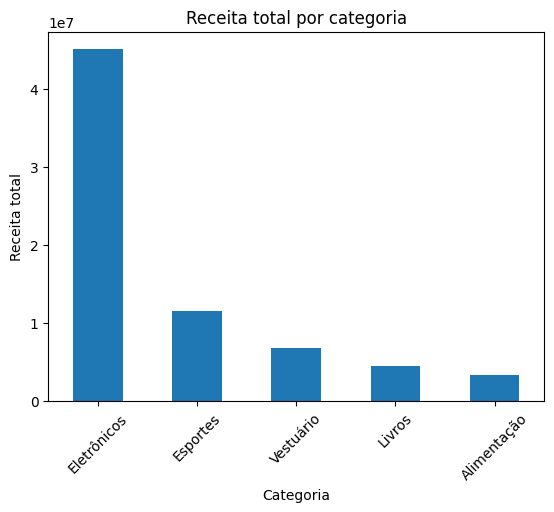

In [36]:
receita_categoria = (df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False))
receita_categoria.plot(kind="bar")
plt.title("Receita total por categoria")
plt.xlabel("Categoria")
plt.ylabel("Receita total")
plt.xticks(rotation=45)
plt.show()

eletronicos estão liderando as vendas

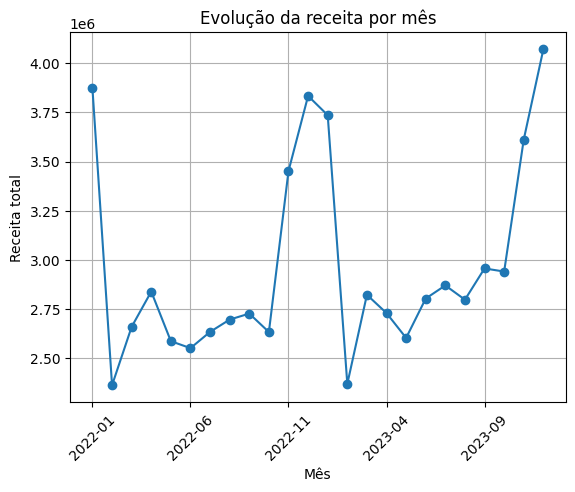

In [37]:
df["mes"] = df["data_venda"].dt.to_period("M")
receita_mes = (df.groupby("mes")["receita_total"].sum())
receita_mes.index = receita_mes.index.astype(str)
receita_mes.plot(kind="line", marker="o")
plt.title("Evolução da receita por mês")
plt.xlabel("Mês")
plt.ylabel("Receita total")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Aparentemente as vendas estão concentradas mais para o final do ano devido aos varios feriados de final de ano

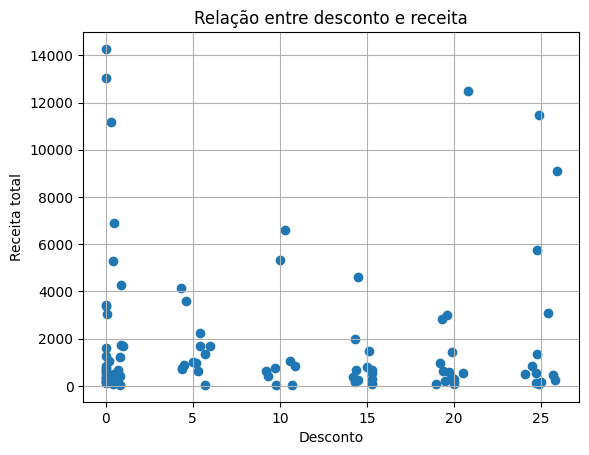

In [38]:
amostra = df.sample(100, random_state=42)
plt.scatter(amostra["desconto_pct"],amostra["receita_total"])
plt.title("Relação entre desconto e receita")
plt.xlabel("Desconto")
plt.ylabel("Receita total")
plt.grid()
plt.show()

os descontos estão concentrados em volta fdos múltiplos de 5%

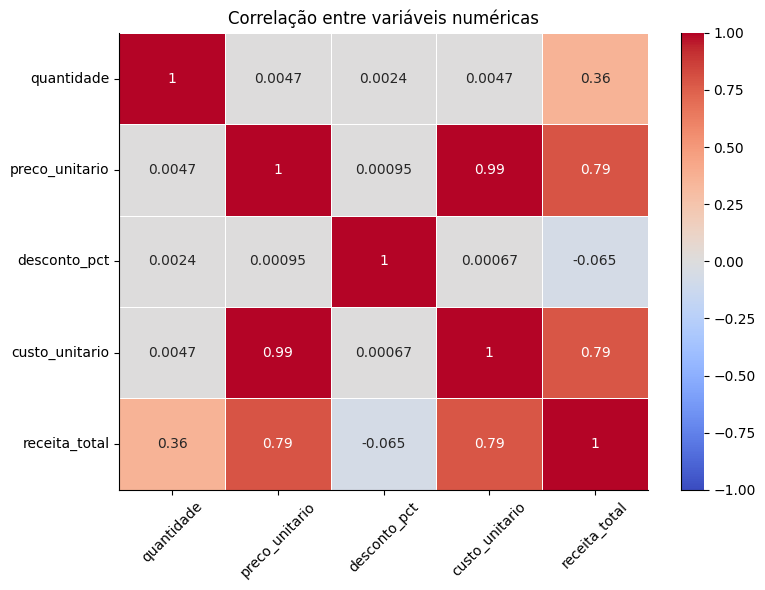

In [39]:
colunas = [
    "quantidade",
    "preco_unitario",
    "desconto_pct",
    "custo_unitario",
    "receita_total"
]


correlacao = df[colunas].corr()


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlação entre variáveis numéricas")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

preço unitario e receita total, bgem como vusto unitario e receira total são fortemente correlacionados, ou seja, quanto mais caro é o preço de um produto, maior será o seu preço unitario e mais receita a sua venda gerará.

desconto não é fortemente correlacionado com nenhum outra variavel encontrada.

quantidade possui uma correlação fraca com receita total, indicando que vender muitas unidades não necessariamente significa tere uma receitra grande.